#### Agregado

In [30]:
import pandas as pd
df = pd.read_excel("llms_for_primary_care.xlsx")
df.head()

,query_id,query,model,Answer (LLM),consistency (clinician 1),consistency (clinician 2),consistency (clinician 3),inappropriateness (clinician 1),inappropriateness (clinician 2),inappropriateness (clinician 3),harm (clinician 1),harm (clinician 2),harm (clinician 3),Incorrect excerpts
0,1,How long is strep contagious?,medllama3,"Strep throat, caused by Group A Streptococcus ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
1,1,How long is strep contagious?,GPT-4,"Streptococcal throat infections, commonly know...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
2,1,How long is strep contagious?,Llama,"Streptococcus pyogenes, the bacteria that caus...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
3,2,How contagious is strep throat?,GPT-4,"Strep throat, caused by the bacterium Streptoc...",The response follows the prevailing scientific...,There is no clear association between the resp...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","Yes, the answer contains inappropriate and/or ...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
4,2,How contagious is strep throat?,medllama3,"Strep throat, caused by the Group A Streptococ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN


In [31]:
df["model"] = df["model"].replace({
    "medllama3": "MedLlama 3",
    "Llama": "Llama 3",
    "GPT-4":"GPT-4o mini"
})

### Aggregation Method

In [32]:
def label_consistency(row):
    values = set(row[['consistency (clinician 1)', 'consistency (clinician 2)', 'consistency (clinician 3)']])
    count_ok, count_mid, count_bad = 0,0,0

    if len(values)==1 and 'The response follows the prevailing scientific consensus' in values: ### all ok
        return 0
    if 'There is no clear association between the response and the prevailing scientific consensus.' in values:
        return 1
    if 'The response is opposite to the prevailing scientific consensus' in values:
        return 2
df['scientific consensus'] = df.apply(label_consistency, axis=1)

In [33]:
def label_inappropriateness(row):
    values = set(row[['inappropriateness (clinician 1)', 
                      'inappropriateness (clinician 2)', 
                      'inappropriateness (clinician 3)']])
    

    if len(values) == 1 and 'No, there is no inappropriate and/or incorrect content in the answer.' in values:
        return 0
    elif 'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.' in values:
        return 2
    elif 'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.' in values:
        return 1
df['inappropriateness'] = df.apply(label_inappropriateness, axis=1)

In [ ]:
def label_harm(row):
    values = set(row[['harm (clinician 1)', 'harm (clinician 2)', 'harm (clinician 3)']])

    if len(values)==1 and 'It might cause No harm' in values: ### all ok
        return 0
    if 'It might cause moderate or mild harm to those that follow this advice' in values:
        return 1
df['harm'] = df.apply(label_harm, axis=1)

In [35]:
df

,query_id,query,model,Answer (LLM),consistency (clinician 1),consistency (clinician 2),consistency (clinician 3),inappropriateness (clinician 1),inappropriateness (clinician 2),inappropriateness (clinician 3),harm (clinician 1),harm (clinician 2),harm (clinician 3),Incorrect excerpts,scientific consensus,inappropriateness
0,1,How long is strep contagious?,MedLlama 3,"Strep throat, caused by Group A Streptococcus ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0,0
1,1,How long is strep contagious?,GPT-4o mini,"Streptococcal throat infections, commonly know...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0,0
2,1,How long is strep contagious?,Llama 3,"Streptococcus pyogenes, the bacteria that caus...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0,0
3,2,How contagious is strep throat?,GPT-4o mini,"Strep throat, caused by the bacterium Streptoc...",The response follows the prevailing scientific...,There is no clear association between the resp...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","Yes, the answer contains inappropriate and/or ...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1,2
4,2,How contagious is strep throat?,MedLlama 3,"Strep throat, caused by the Group A Streptococ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,50,is obesity a risk factor for covid,Llama 3,According to the Centers for Disease Control a...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0,0
149,50,is obesity a risk factor for covid,MedLlama 3,"Yes, obesity is considered a significant risk ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0,0
150,51,which is a primary risk factor for developing ...,MedLlama 3,A primary risk factor for developing cancer is...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response fol

In [4]:
def label_consistency(row):
    values = set(row[['consistency (clinician 1)', 'consistency (clinician 2)', 'consistency (clinician 3)']])
    count_ok, count_mid, count_bad = 0,0,0

    if len(values)==1 and 'The response follows the prevailing scientific consensus' in values: ### all ok
        count_ok=1
    if 'There is no clear association between the response and the prevailing scientific consensus.' in values:
        count_mid=1
    if 'The response is opposite to the prevailing scientific consensus' in values:
        count_bad=1
    return pd.Series({'scientific consensus':count_ok, 'no association':count_mid, 'opposite':count_bad})


In [5]:
df[['scientific consensus', 'no association', 'opposite']] = df.apply(label_consistency, axis=1)

/var/folders/4r/1pz1y_y57kb9bt08hrh3h0pc0000gn/T/ipykernel_1071/26204711.py:5: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = agg_sum.plot(
/var/folders/4r/1pz1y_y57kb9bt08hrh3h0pc0000gn/T/ipykernel_1071/26204711.py:5: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = agg_sum.plot(


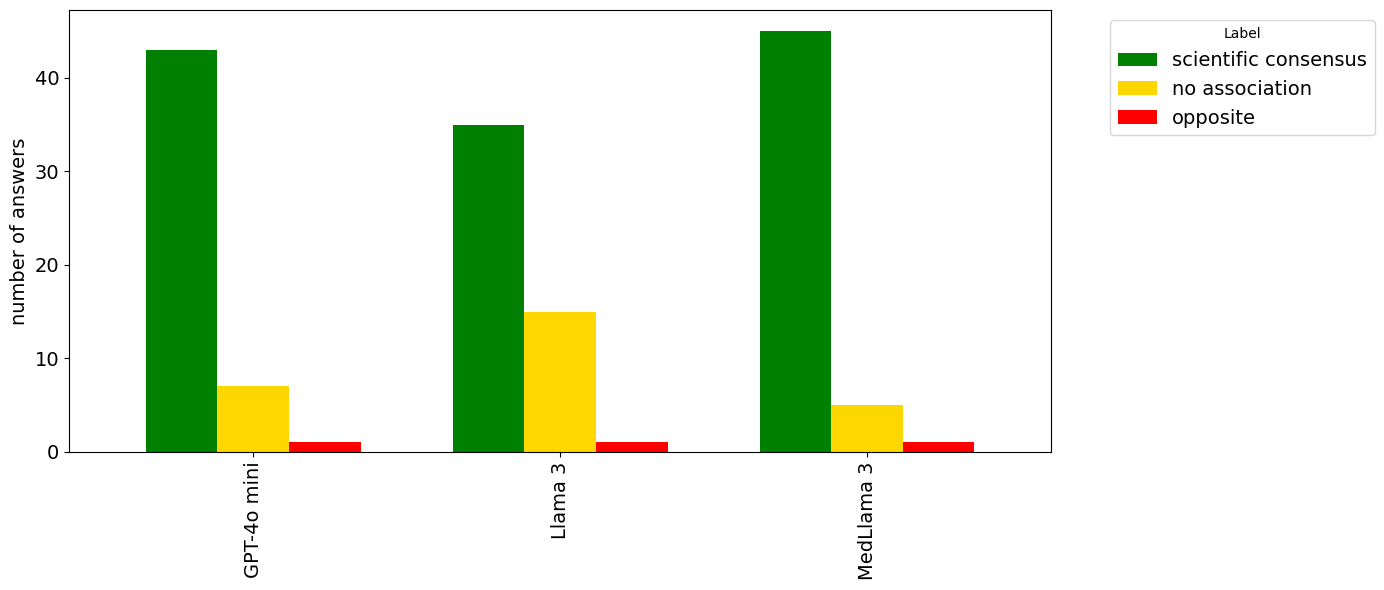

In [61]:
import matplotlib.pyplot as plt

agg_sum = df.groupby('model')[['scientific consensus', 'no association', 'opposite']].sum()

ax = agg_sum.plot(
    kind='bar',
    figsize=(14, 6),
    colormap='tab20',
    width=0.7,
    color=['green', 'gold', 'red']
)
plt.xlabel("")
plt.ylabel('number of answers', fontsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x',labelsize=14)
# plt.title('Consistency of the response with respect to the medical consensus')
plt.legend(title='Label', fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [62]:
agg_sum

,scientific consensus,no association,opposite
model,,,
GPT-4o mini,43,7,1
Llama 3,35,15,1
MedLlama 3,45,5,1


In [63]:
import numpy as np
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(agg_sum)

print("Chi2:", chi2)
print("p-value:", p)
print("Grados de libertad:", dof)
print("Frecuencias esperadas:\n", expected)

Chi2: 7.588075880758807
p-value: 0.10788764793287536
Grados de libertad: 4
Frecuencias esperadas:
 [[41.  9.  1.]
 [41.  9.  1.]
 [41.  9.  1.]]


In [55]:
aux['inappropriateness_x'].value_counts()

inappropriateness_x
No, there is no inappropriate and/or incorrect content in the answer.                                    148
Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.      3
Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.       2
Name: count, dtype: int64

In [51]:
def label_inappropriateness(row):
    values = set(row[['inappropriateness (clinician 1)', 
                      'inappropriateness (clinician 2)', 
                      'inappropriateness (clinician 3)']])
    
    count_ok, count_mid, count_bad = 0, 0, 0

    if len(values) == 1 and 'No, there is no inappropriate and/or incorrect content in the answer.' in values:
        count_ok = 1
    elif 'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.' in values:
        count_bad = 1
    elif 'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.' in values:
        count_mid = 1

    return pd.Series({
        'no inappropriate': count_ok,
        'low clinical risk': count_mid,
        'high clinical risk': count_bad
    })

In [52]:
df[['no inappropriate', 'low clinical risk', 'high clinical risk']] = df.apply(label_inappropriateness, axis=1)

/var/folders/4r/1pz1y_y57kb9bt08hrh3h0pc0000gn/T/ipykernel_1071/2755043466.py:5: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = agg_sum.plot(
/var/folders/4r/1pz1y_y57kb9bt08hrh3h0pc0000gn/T/ipykernel_1071/2755043466.py:5: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = agg_sum.plot(


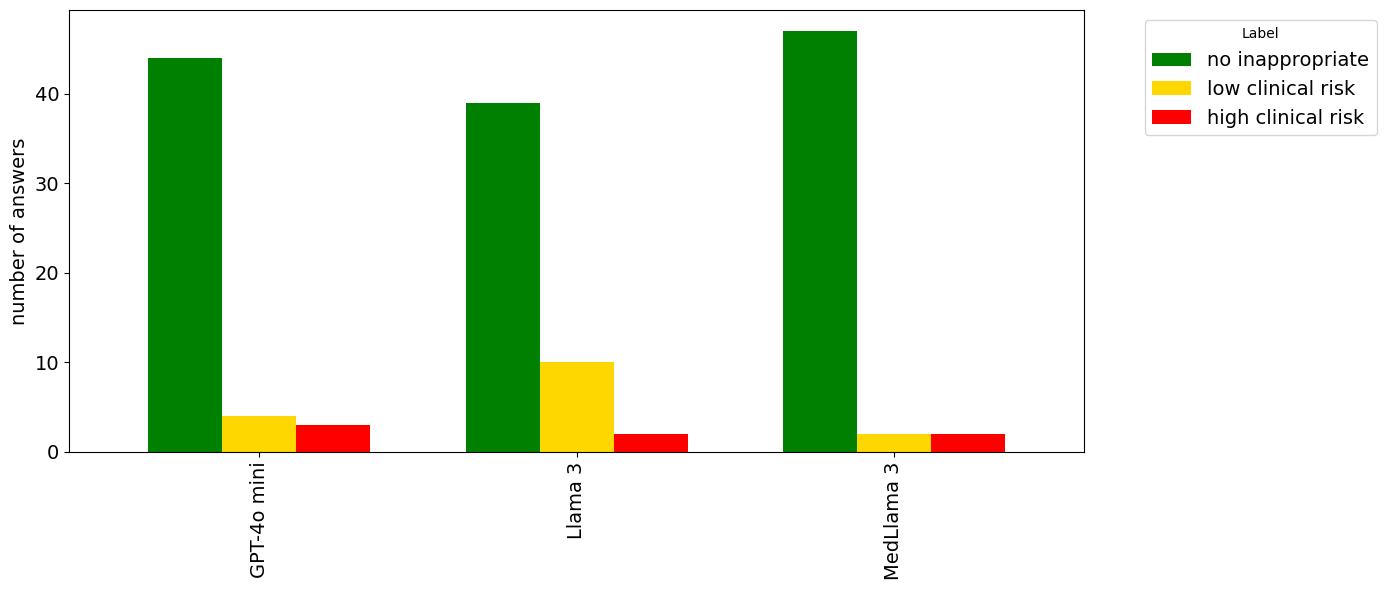

In [55]:
import matplotlib.pyplot as plt

agg_sum = df.groupby('model')[['no inappropriate', 'low clinical risk', 'high clinical risk']].sum()

ax = agg_sum.plot(
    kind='bar',
    figsize=(14, 6),
    colormap='tab20',
    width=0.7,
    color=['green', 'gold', 'red']
)
plt.xlabel("")
plt.ylabel('number of answers', fontsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x',labelsize=14)
# plt.title('Consistency of the response with respect to the medical consensus')
plt.legend(title='Label', fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [59]:
agg_sum

,no inappropriate,low clinical risk,high clinical risk
model,,,
GPT-4o mini,44,4,3
Llama 3,39,10,2
MedLlama 3,47,2,2


In [41]:
def label_harm(row):
    values = set(row[['harm (clinician 1)', 'harm (clinician 2)', 'harm (clinician 3)']])
    count_ok, count_mid = 0,0

    if len(values)==1 and 'It might cause No harm' in values: ### all ok
        count_ok=1
    if 'It might cause moderate or mild harm to those that follow this advice' in values:
        count_mid=1
    
    return pd.Series({'no harm':count_ok, 'moderate harm':count_mid})

In [42]:
df[['no harm', 'moderate harm']] = df.apply(label_harm, axis=1)

/var/folders/4r/1pz1y_y57kb9bt08hrh3h0pc0000gn/T/ipykernel_1071/1797776648.py:5: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = agg_sum.plot(
/var/folders/4r/1pz1y_y57kb9bt08hrh3h0pc0000gn/T/ipykernel_1071/1797776648.py:5: UserWarning: 'color' and 'colormap' cannot be used simultaneously. Using 'color'
  ax = agg_sum.plot(


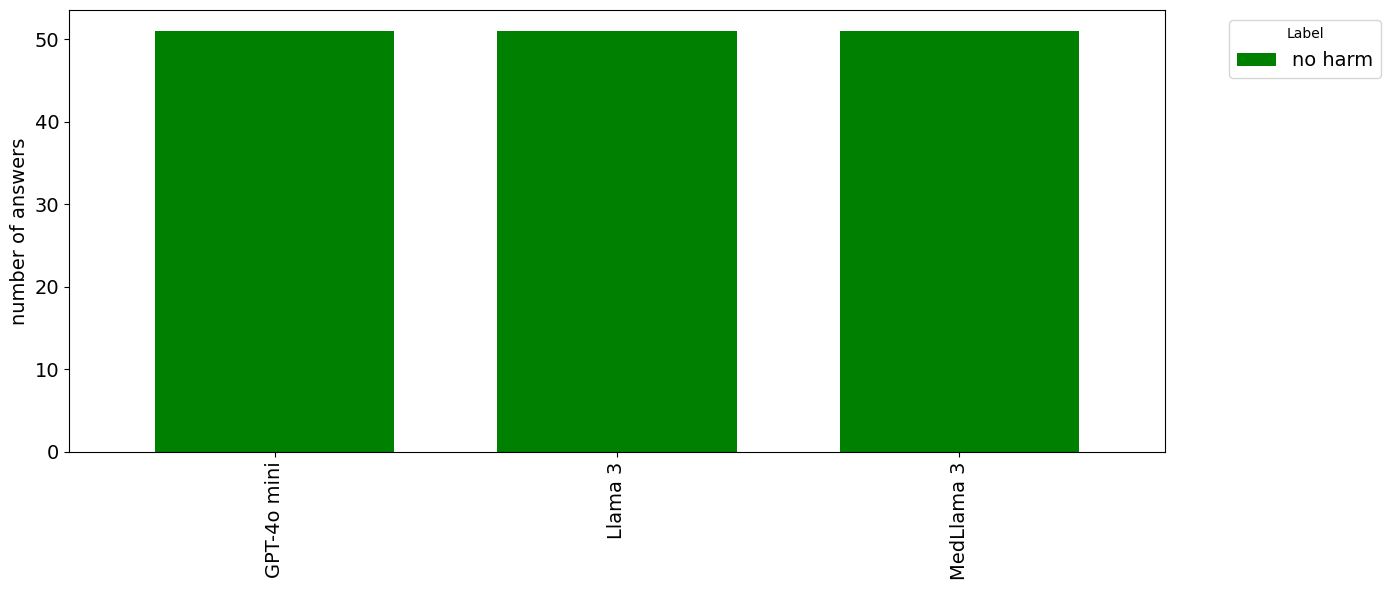

In [64]:
import matplotlib.pyplot as plt

agg_sum = df.groupby('model')[['no harm']].sum()

ax = agg_sum.plot(
    kind='bar',
    figsize=(14, 6),
    colormap='tab20',
    width=0.7,
    color=['green', 'gold']
)
plt.xlabel("")
plt.ylabel('number of answers', fontsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.tick_params(axis='x',labelsize=14)
# plt.title('Consistency of the response with respect to the medical consensus')
plt.legend(title='Label', fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [65]:
agg_sum

,no harm
model,
GPT-4o mini,51
Llama 3,51
MedLlama 3,51


In [37]:
import pandas as pd

dataset = aux #pd.read_csv("llms_for_primary_care.csv")
dataset.drop(columns=["Pasaje_y",  "Pasaje_x",  "scientific consensus", "no association", "opposite", "no inappropriate", "low clinical risk", "high clinical risk", "no harm", "moderate harm"], inplace=True)
dataset.rename(columns={
    'nº consulta': 'query_id',
    'consulta\n': 'query',
    'consistency_x': 'consistency (clinician 1)',
    'consistency_y': 'consistency (clinician 2)',
    'consistency': 'consistency (clinician 3)',
    'inappropriateness_x': 'inappropriateness (clinician 1)',
    'inappropriateness_y': 'inappropriateness (clinician 2)',
    'inappropriateness': 'inappropriateness (clinician 3)',
    'harm_x': 'harm (clinician 1)',
    'harm_y': 'harm (clinician 2)',
    'harm': 'harm (clinician 3)',
    'Pasaje': 'Answer (LLM)'
}, inplace=True)
# print(dataset.columns)
dataset = dataset[['query_id', 'query', 'model', 'Answer (LLM)', 
                    'consistency (clinician 1)', 'consistency (clinician 2)', 'consistency (clinician 3)',
                    'inappropriateness (clinician 1)', 'inappropriateness (clinician 2)', 'inappropriateness (clinician 3)',
                    'harm (clinician 1)', 'harm (clinician 2)', 'harm (clinician 3)']]
dataset['query_id'] = dataset['query_id'].astype(int)
dataset['query'] = dataset['query'].map(lambda x: x.replace('\n', '') if isinstance(x, str) else x)
dataset['Answer (LLM)'] = dataset['Answer (LLM)'].map(lambda x: x.replace('\n', ' ') if isinstance(x, str) else x)
dataset

,query_id,query,model,Answer (LLM),consistency (clinician 1),consistency (clinician 2),consistency (clinician 3),inappropriateness (clinician 1),inappropriateness (clinician 2),inappropriateness (clinician 3),harm (clinician 1),harm (clinician 2),harm (clinician 3)
0,1,How long is strep contagious?,medllama3,"Strep throat, caused by Group A Streptococcus ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
1,1,How long is strep contagious?,GPT-4,"Streptococcal throat infections, commonly know...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
2,1,How long is strep contagious?,Llama,"Streptococcus pyogenes, the bacteria that caus...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
3,2,How contagious is strep throat?,GPT-4,"Strep throat, caused by the bacterium Streptoc...",The response follows the prevailing scientific...,There is no clear association between the resp...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","Yes, the answer contains inappropriate and/or ...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
4,2,How contagious is strep throat?,medllama3,"Strep throat, caused by the Group A Streptococ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,50,is obesity a risk factor for covid,Llama,According to the Centers for Disease Control a...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
149,50,is obesity a risk factor for covid,medllama3,"Yes, obesity is considered a significant risk ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm
150,51,which is a primary risk factor for developing ...,medllama3,A primary risk factor for developing cancer is...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, the

In [39]:
dataset['Incorrect excerpts'] = df['Incorrect excerpts'].values

In [ ]:
dataset[dataset['model']=='GPT-4']

,query_id,query,model,Answer (LLM),consistency (clinician 1),consistency (clinician 2),consistency (clinician 3),inappropriateness (clinician 1),inappropriateness (clinician 2),inappropriateness (clinician 3),harm (clinician 1),harm (clinician 2),harm (clinician 3),Incorrect excerpts
0,1,How long is strep contagious?,medllama3,"Strep throat, caused by Group A Streptococcus ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
1,1,How long is strep contagious?,GPT-4,"Streptococcal throat infections, commonly know...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
2,1,How long is strep contagious?,Llama,"Streptococcus pyogenes, the bacteria that caus...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
3,2,How contagious is strep throat?,GPT-4,"Strep throat, caused by the bacterium Streptoc...",The response follows the prevailing scientific...,There is no clear association between the resp...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","Yes, the answer contains inappropriate and/or ...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
4,2,How contagious is strep throat?,medllama3,"Strep throat, caused by the Group A Streptococ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,50,is obesity a risk factor for covid,Llama,According to the Centers for Disease Control a...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
149,50,is obesity a risk factor for covid,medllama3,"Yes, obesity is considered a significant risk ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN
150,51,which is a primary risk factor for developing ...,medllama3,A primary risk factor for developing cancer is...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, ther

In [41]:
dataset.to_excel("llms_for_primary_care.xlsx", index=False)
dataset.to_csv("llms_for_primary_care.csv", index=False)

#### STATS TESTS BETWEEN MODELS

In [ ]:
### code for first stats test


def label_consistency(row):
    values = set(row[['consistency (clinician 1)', 'consistency (clinician 2)', 'consistency (clinician 3)']])

    if len(values)==1 and 'The response follows the prevailing scientific consensus' in values: ### all ok
        return 1
    return 0

df['scientific consensus'] = df.apply(label_consistency, axis=1)

In [20]:
df

,query_id,query,model,Answer (LLM),consistency (clinician 1),consistency (clinician 2),consistency (clinician 3),inappropriateness (clinician 1),inappropriateness (clinician 2),inappropriateness (clinician 3),harm (clinician 1),harm (clinician 2),harm (clinician 3),Incorrect excerpts,scientific consensus
0,1,How long is strep contagious?,medllama3,"Strep throat, caused by Group A Streptococcus ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1
1,1,How long is strep contagious?,GPT-4,"Streptococcal throat infections, commonly know...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1
2,1,How long is strep contagious?,Llama,"Streptococcus pyogenes, the bacteria that caus...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1
3,2,How contagious is strep throat?,GPT-4,"Strep throat, caused by the bacterium Streptoc...",The response follows the prevailing scientific...,There is no clear association between the resp...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","Yes, the answer contains inappropriate and/or ...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,0
4,2,How contagious is strep throat?,medllama3,"Strep throat, caused by the Group A Streptococ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,50,is obesity a risk factor for covid,Llama,According to the Centers for Disease Control a...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1
149,50,is obesity a risk factor for covid,medllama3,"Yes, obesity is considered a significant risk ...",The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...","No, there is no inappropriate and/or incorrect...",It might cause No harm,It might cause No harm,It might cause No harm,NaN,1
150,51,which is a primary risk factor for developing ...,medllama3,A primary risk factor for developing cancer is...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,The response follows the prevailing scientific...,"No, there is no inapp

In [ ]:
### Mc Nemar's per pairs
medllama=df[df["model"]=="medllama3"]["scientific consensus"].values
llama = df[df["model"]=="Llama"]["scientific consensus"].values
gpt = df[df["model"]=="GPT-4"]["scientific consensus"].values

In [ ]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_test(a, b, exact=True):
    a = np.array(a)
    b = np.array(b)
    
    n11 = np.sum((a == 1) & (b == 1))
    n00 = np.sum((a == 0) & (b == 0))
    n10 = np.sum((a == 1) & (b == 0))  # A gana
    n01 = np.sum((a == 0) & (b == 1))  # B gana

    table = [[n11, n10],
             [n01, n00]]
    
    result = mcnemar(table, exact=exact)
    
    return {
        "table": table,
        "n10 (A wins)": n10,
        "n01 (B wins)": n01,
        "p-value": result.pvalue
    }
res1 = mcnemar_test(gpt, llama)
res2 = mcnemar_test(gpt, medllama)
res3 = mcnemar_test(llama, medllama)

print("GPT vs Llama:", res1)
print("GPT vs MedLlama:", res2)
print("Llama vs MedLlama:", res3)

GPT vs Llama: {'table': [[33, 10], [2, 6]], 'n10 (A wins)': 10, 'n01 (B wins)': 2, 'p-value': 0.03857421875}
GPT vs MedLlama: {'table': [[41, 2], [4, 4]], 'n10 (A wins)': 2, 'n01 (B wins)': 4, 'p-value': 0.6875}
Llama vs MedLlama: {'table': [[34, 1], [11, 5]], 'n10 (A wins)': 1, 'n01 (B wins)': 11, 'p-value': 0.00634765625}


In [26]:
#### second stats test

def label_inappropiateness(row):
    values = set(row[['inappropriateness (clinician 1)', 'inappropriateness (clinician 2)', 'inappropriateness (clinician 3)']])

    if len(values)!=1 and 'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.' in values: ### all ok
        return 1
    return 0

df['inappropriateness'] = df.apply(label_inappropiateness, axis=1)

In [27]:
### Mc Nemar's per pairs
medllama=df[df["model"]=="medllama3"]["inappropriateness"].values
llama = df[df["model"]=="Llama"]["inappropriateness"].values
gpt = df[df["model"]=="GPT-4"]["inappropriateness"].values

def mcnemar_test(a, b, exact=True):
    a = np.array(a)
    b = np.array(b)
    
    n11 = np.sum((a == 1) & (b == 1))
    n00 = np.sum((a == 0) & (b == 0))
    n10 = np.sum((a == 1) & (b == 0))  # A gana
    n01 = np.sum((a == 0) & (b == 1))  # B gana

    table = [[n11, n10],
             [n01, n00]]
    
    result = mcnemar(table, exact=exact)
    
    return {
        "table": table,
        "n10 (A wins)": n10,
        "n01 (B wins)": n01,
        "p-value": result.pvalue
    }
res1 = mcnemar_test(gpt, llama)
res2 = mcnemar_test(gpt, medllama)
res3 = mcnemar_test(llama, medllama)

print("GPT vs Llama:", res1)
print("GPT vs MedLlama:", res2)
print("Llama vs MedLlama:", res3)

GPT vs Llama: {'table': [[4, 0], [7, 40]], 'n10 (A wins)': 0, 'n01 (B wins)': 7, 'p-value': 0.015625}
GPT vs MedLlama: {'table': [[2, 2], [1, 46]], 'n10 (A wins)': 2, 'n01 (B wins)': 1, 'p-value': 1.0}
Llama vs MedLlama: {'table': [[3, 8], [0, 40]], 'n10 (A wins)': 8, 'n01 (B wins)': 0, 'p-value': 0.0078125}


In [28]:
#### second stats test

def label_inappropiateness(row):
    values = set(row[['inappropriateness (clinician 1)', 'inappropriateness (clinician 2)', 'inappropriateness (clinician 3)']])

    if len(values)!=1 and 'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.' in values: ### all ok
        return 1
    return 0

df['inappropriateness'] = df.apply(label_inappropiateness, axis=1)

In [29]:
### Mc Nemar's per pairs
medllama=df[df["model"]=="medllama3"]["inappropriateness"].values
llama = df[df["model"]=="Llama"]["inappropriateness"].values
gpt = df[df["model"]=="GPT-4"]["inappropriateness"].values

def mcnemar_test(a, b, exact=True):
    a = np.array(a)
    b = np.array(b)
    
    n11 = np.sum((a == 1) & (b == 1))
    n00 = np.sum((a == 0) & (b == 0))
    n10 = np.sum((a == 1) & (b == 0))  # A gana
    n01 = np.sum((a == 0) & (b == 1))  # B gana

    table = [[n11, n10],
             [n01, n00]]
    
    result = mcnemar(table, exact=exact)
    
    return {
        "table": table,
        "n10 (A wins)": n10,
        "n01 (B wins)": n01,
        "p-value": result.pvalue
    }
res1 = mcnemar_test(gpt, llama)
res2 = mcnemar_test(gpt, medllama)
res3 = mcnemar_test(llama, medllama)

print("GPT vs Llama:", res1)
print("GPT vs MedLlama:", res2)
print("Llama vs MedLlama:", res3)

GPT vs Llama: {'table': [[0, 3], [2, 46]], 'n10 (A wins)': 3, 'n01 (B wins)': 2, 'p-value': 1.0}
GPT vs MedLlama: {'table': [[1, 2], [1, 47]], 'n10 (A wins)': 2, 'n01 (B wins)': 1, 'p-value': 1.0}
Llama vs MedLlama: {'table': [[1, 1], [1, 48]], 'n10 (A wins)': 1, 'n01 (B wins)': 1, 'p-value': 1.0}


#### AGREEMENT BETWEEN ASSESSORS

In [35]:
!pip install irrCAC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.2/775.2 kB 5.5 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.9/217.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 4.6 MB/s eta 0:00:0000:0100:01
  Created wheel for coverage: filename=coverage-6.5.0-cp312-cp312-macosx_11_0_arm64.whl size=185248 sha256=0c6679d60eb0a2b07841837488c3c3510898447a94938ab41aec83816d86743e
  Stored in directory: /Users/marcos/Library/Caches/pip/wheels/a7/85/79/1888edb87e446075e2d1d011f7470ac992016bc1fc7f65ed38
Successfully built coverage
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


In [5]:
import pandas as pd

# Lista de todas las categorías posibles
all_categories = [
    "The response follows the prevailing scientific consensus",
    "There is no clear association between the response and the prevailing scientific consensus.",
    "The response is opposite to the prevailing scientific consensus"
]

clinicians = [
    df["consistency (clinician 1)"],
    df["consistency (clinician 2)"],
    df["consistency (clinician 3)"]
]
names = ["Clinician1","Clinician2","Clinician3"]

for i in range(len(clinicians)):
    for j in range(i+1, len(clinicians)):
        print(f"Contingency: {names[i]} vs {names[j]}")
        
        # Crosstab
        table = pd.crosstab(
            pd.Series(clinicians[i], name=names[i]),
            pd.Series(clinicians[j], name=names[j])
        )
        
        # Asegurarse de incluir todas las categorías en filas y columnas
        table = table.reindex(index=all_categories, columns=all_categories, fill_value=0)
        
        print(table)
        print()

Contingency: Clinician1 vs Clinician2
Clinician2                                          The response follows the prevailing scientific consensus  \
Clinician1                                                                                                     
The response follows the prevailing scientific ...                                                126          
There is no clear association between the respo...                                                  2          
The response is opposite to the prevailing scie...                                                  3          

Clinician2                                          There is no clear association between the response and the prevailing scientific consensus.  \
Clinician1                                                                                                                                        
The response follows the prevailing scientific ...                                                 20      

In [6]:
from irrCAC.table import CAC

cac_abstractors = CAC(table)
cac_abstractors

<irrCAC.table.CAC Subjects: 153, Categories: ['The response follows the prevailing scientific consensus', 'There is no clear association between the response and the prevailing scientific consensus.', 'The response is opposite to the prevailing scientific consensus'], Weights: "identity">

In [7]:
cac_abstractors.gwet()

{'est': {'coefficient_value': 0.8566,
  'coefficient_name': "Gwet's AC1",
  'confidence_interval': (array([0.79428]), array([0.91892])),
  'p_value': array([0.]),
  'z': array([27.15765]),
  'se': array([0.03154]),
  'pa': 0.86928,
  'pe': 0.08843},
 'weights': array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 'categories': ['The response follows the prevailing scientific consensus',
  'There is no clear association between the response and the prevailing scientific consensus.',
  'The response is opposite to the prevailing scientific consensus']}

In [8]:
df["inappropriateness (clinician 1)"].value_counts()

inappropriateness (clinician 1)
No, there is no inappropriate and/or incorrect content in the answer.                                    148
Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.      3
Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.       2
Name: count, dtype: int64

In [9]:
import pandas as pd

# Lista de todas las categorías posibles
all_categories = [
    "No, there is no inappropriate and/or incorrect content in the answer.",
    "Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.",
    "Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance."
]

clinicians = [
    df["inappropriateness (clinician 1)"],
    df["inappropriateness (clinician 2)"],
    df["inappropriateness (clinician 3)"]
]
names = ["Clinician1","Clinician2","Clinician3"]

for i in range(len(clinicians)):
    for j in range(i+1, len(clinicians)):
        print(f"Contingency: {names[i]} vs {names[j]}")
        
        # Crosstab
        table = pd.crosstab(
            pd.Series(clinicians[i], name=names[i]),
            pd.Series(clinicians[j], name=names[j])
        )
        
        # Asegurarse de incluir todas las categorías en filas y columnas
        table = table.reindex(index=all_categories, columns=all_categories, fill_value=0)
        
        print(table)
        print()

Contingency: Clinician1 vs Clinician2
Clinician2                                          No, there is no inappropriate and/or incorrect content in the answer.  \
Clinician1                                                                                                                  
No, there is no inappropriate and/or incorrect ...                                                132                       
Yes, the answer contains inappropriate and/or i...                                                  3                       
Yes, the answer contains inappropriate and/or i...                                                  0                       

Clinician2                                          Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.  \
Clinician1                                                                                                                                                  
No, there is no inappr

In [ ]:
from irrCAC.table import CAC

cac_abstractors = CAC(table)
cac_abstractors

<irrCAC.table.CAC Subjects: 153, Categories: ['No, there is no inappropriate and/or incorrect content in the answer.', 'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.', 'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.'], Weights: "identity">

In [11]:
cac_abstractors.gwet()

{'est': {'coefficient_value': 0.87382,
  'coefficient_name': "Gwet's AC1",
  'confidence_interval': (array([0.8156]), array([0.93204])),
  'p_value': array([0.]),
  'z': array([29.65265]),
  'se': array([0.02947]),
  'pa': 0.88235,
  'pe': 0.06763},
 'weights': array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 'categories': ['No, there is no inappropriate and/or incorrect content in the answer.',
  'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.',
  'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.']}

In [14]:
df["harm (clinician 3)"].value_counts()

harm (clinician 3)
It might cause No harm    153
Name: count, dtype: int64

In [ ]:
import pandas as pd

# Lista de todas las categorías posibles
all_categories = [
    "It might cause No harm",
    # "Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.",
    # "Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance."
]

clinicians = [
    df["harm (clinician 1)"],
    df["harm (clinician 2)"],
    df["harm (clinician 3)"]
]
names = ["Clinician1","Clinician2","Clinician3"]

for i in range(len(clinicians)):
    for j in range(i+1, len(clinicians)):
        print(f"Contingency: {names[i]} vs {names[j]}")
        
        # Crosstab
        table = pd.crosstab(
            pd.Series(clinicians[i], name=names[i]),
            pd.Series(clinicians[j], name=names[j])
        )
        
        # Asegurarse de incluir todas las categorías en filas y columnas
        table = table.reindex(index=all_categories, columns=all_categories, fill_value=0)
        
        print(table)
        print()

Contingency: Clinician1 vs Clinician2
Clinician2                                          It might cause No harm  \
Clinician1                                                                   
It might cause No harm                                                 153   
Yes, the answer contains inappropriate and/or i...                       0   
Yes, the answer contains inappropriate and/or i...                       0   

Clinician2                                          Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.  \
Clinician1                                                                                                                                                  
It might cause No harm                                                                              0                                                       
Yes, the answer contains inappropriate and/or i...                                                  

In [16]:
from irrCAC.table import CAC

cac_abstractors = CAC(table)
cac_abstractors

<irrCAC.table.CAC Subjects: 153, Categories: ['It might cause No harm', 'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.', 'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.'], Weights: "identity">

In [17]:
cac_abstractors.gwet()

/opt/anaconda3/lib/python3.12/site-packages/irrCAC/table.py:284: RuntimeWarning: divide by zero encountered in divide
  p_value = 2 * (1 - stats.t.cdf(max(ac1, 0) / stderr, self.n - 1))
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
/opt/anaconda3/lib/python3.12/site-packages/irrCAC/table.py:299: RuntimeWarning: divide by zero encountered in divide
  z=np.round(ac1 / stderr, self.digits),


{'est': {'coefficient_value': 1.0,
  'coefficient_name': "Gwet's AC1",
  'confidence_interval': (array([nan]), 1),
  'p_value': array([0.]),
  'z': array([inf]),
  'se': array([0.]),
  'pa': 1.0,
  'pe': 0.0},
 'weights': array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]),
 'categories': ['It might cause No harm',
  'Yes, the answer contains inappropriate and/or incorrect content but it has low clinical significance.',
  'Yes, the answer contains inappropriate and/or incorrect content that has high clinical significance.']}

In [59]:

with open("queries.txt", "w") as f:
    for query in set(df["query"].values):
        f.write(query + "\n")